# Dialogue-derived probes, base-model arm (Q1.H2.E3)

Tests the story-to-dialogue transfer explanation for the E1/E2 nulls: probes rebuilt from
two-person dialogues (12 battery emotions x 16 dialogues, generated by the base model itself,
`scripts/generate_dialogue_stories.py`), extracted with the standard pipeline
(`results/dialogue_vectors/`), scored on the same battery activations as E2.

**Known confound, measured before scoring**: 44% of the generated dialogues name their emotion
despite the instruction (vs 4% in the original 4B story corpus) — base-model instruction
following. Scoring therefore runs three probe sets: (A) story probes re-centered within the 12
battery emotions (baseline), (B) dialogue probes, all 16 per emotion, (C) dialogue probes from
non-leaking dialogues only (small n — reported per emotion). If B works mainly where leakage is
high, that is lexical encoding, not concept transfer.

**Registered scoring points** (TREE.md Q1.H2.E3): layers 33 and 39, plus the sweep's best
unconfirmed combination (layer 57), last-token readout, both batteries. Centering for every
probe set is within the same 12 emotions, so A vs B is apples-to-apples.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import rankdata

from emotion_vectors.probe_prompts import SCENARIOS
from emotion_vectors.story_store import emotion_mean, load_manifest

ROOT = Path("..")
probe_order = [t for _, t, _ in SCENARIOS]
STEMS = {"happy": ["happy", "happi"], "inspired": ["inspir"], "loving": ["love", "loving"],
         "proud": ["proud", "pride"], "calm": ["calm"], "desperate": ["desperat"],
         "angry": ["angry", "anger"], "guilty": ["guilt"], "sad": ["sad"],
         "afraid": ["afraid", "fear"], "nervous": ["nervous"], "surprised": ["surpris"]}

# story probes (171-corpus means), restricted to the 12
bundle = np.load(ROOT / "results/emotion_vectors/emotion_means.npz", allow_pickle=True)
s_emotions, layers, s_means = list(map(str, bundle["emotions"])), list(bundle["layers"]), bundle["means"]
story12 = np.stack([s_means[s_emotions.index(e)] for e in probe_order])  # [12, layers, d_model]

# dialogue probes: token-weighted means from shards, full and leak-filtered
dv = ROOT / "results/dialogue_vectors"
manifest = [r for r in load_manifest(dv / "manifest.jsonl").values() if r.get("error") is None]
rows_by_emotion = {}
for r in manifest:
    rows_by_emotion.setdefault(r["emotion"], []).append(r)
texts = {json.loads(l)["emotion"]: json.loads(l)["stories"]
         for l in open(ROOT / "results/dialogue_stories/dialogues_grouped.jsonl")}
leak = {e: [any(st in t.lower() for st in STEMS[e]) for t in texts[e]] for e in probe_order}

def dialogue_means(keep_leaky):
    out, kept = [], {}
    for e in probe_order:
        rows = [r for r in rows_by_emotion[e] if keep_leaky or not leak[e][r["story_index"]]]
        kept[e] = len(rows)
        out.append(emotion_mean(dv, rows))
    return np.stack(out), kept  # [12, layers, d_model]

dlg_full, kept_full = dialogue_means(True)
dlg_clean, kept_clean = dialogue_means(False)
print("leakage per emotion:", {e: sum(v) for e, v in leak.items()})
print("clean-probe n per emotion:", kept_clean)

sweep = np.load(ROOT / "results/probe_sweep/activations.npz", allow_pickle=True)
prompts = [json.loads(l) for l in open(ROOT / "results/probe_sweep/prompts.jsonl")]
acts_last = sweep["plain_last"].astype(np.float32)  # [n_prompts, layers, d_model]
batteries = {k: [i for i, p in enumerate(prompts) if p["kind"] == k] for k in ("scenario", "heldout")}

leakage per emotion: {'happy': 9, 'inspired': 10, 'loving': 11, 'proud': 12, 'calm': 11, 'desperate': 2, 'angry': 4, 'guilty': 2, 'sad': 3, 'afraid': 4, 'nervous': 11, 'surprised': 5}
clean-probe n per emotion: {'happy': 7, 'inspired': 6, 'loving': 5, 'proud': 4, 'calm': 5, 'desperate': 14, 'angry': 12, 'guilty': 14, 'sad': 13, 'afraid': 12, 'nervous': 5, 'surprised': 11}


## Scoring: story vs dialogue probes, both batteries

**How to read the table**: each row is (probe set, layer); columns give how many of the 12
scenarios put their target emotion in the top 3 of 12 probes (chance ~3, registered pass 8)
for the paper battery and our held-out battery, plus mean diagonal-minus-off-diagonal cosine.
The E3 expectation: if story-to-dialogue transfer caused the null, dialogue probes (B) beat
story probes (A). If (B) beats (A) only via high-leakage emotions, compare with (C).

In [2]:
def score(probe_means, layer, kind):
    lp = layers.index(layer)
    P = probe_means[:, lp, :] - probe_means[:, lp, :].mean(axis=0)
    P = P / np.linalg.norm(P, axis=1, keepdims=True)
    A = acts_last[batteries[kind], lp, :]
    M = P @ A.T / np.linalg.norm(A, axis=1)
    ranks = [int(12 - rankdata(M[:, j])[j]) + 1 for j in range(12)]
    diag = np.mean([M[j, j] for j in range(12)])
    off = np.mean([M[i, j] for i in range(12) for j in range(12) if i != j])
    return sum(r <= 3 for r in ranks), diag - off, M, ranks

SETS = {"A story-probes": story12, "B dialogue-full": dlg_full, "C dialogue-clean": dlg_clean}
print(f"{'probe set':18s} {'layer':>5s} {'paper':>6s} {'heldout':>8s} {'diag-off (paper)':>17s}")
results = {}
for name, pm in SETS.items():
    for layer in (33, 39, 57):
        t_p, d_p, M, _ = score(pm, layer, "scenario")
        t_h, d_h, _, _ = score(pm, layer, "heldout")
        results[(name, layer)] = (t_p, t_h, M)
        print(f"{name:18s} {layer:5d} {t_p:4d}/12 {t_h:6d}/12 {d_p:17.4f}")

probe set          layer  paper  heldout  diag-off (paper)
A story-probes        33    3/12      3/12            0.0047
A story-probes        39    3/12      3/12            0.0244
A story-probes        57    7/12      4/12            0.0234
B dialogue-full       33    3/12      3/12            0.0091
B dialogue-full       39    4/12      5/12            0.0598
B dialogue-full       57    6/12      7/12            0.0703
C dialogue-clean      33    3/12      3/12            0.0058
C dialogue-clean      39    5/12      6/12            0.0384
C dialogue-clean      57    4/12      6/12            0.0438


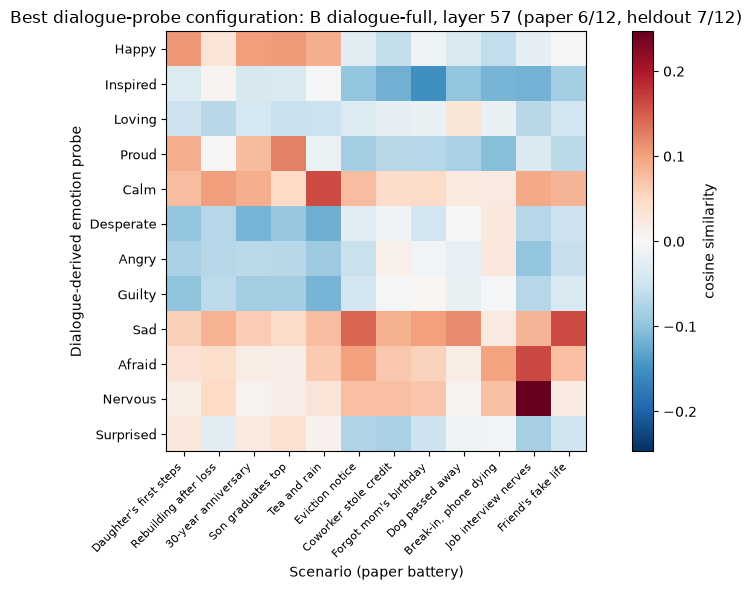

In [3]:
best = max(((k, v) for k, v in results.items() if k[0].startswith("B")),
           key=lambda kv: kv[1][0] + kv[1][1])
(bname, blayer), (bt_p, bt_h, bM) = best
scen_names = [prompts[i]["name"] for i in batteries["scenario"]]
fig, ax = plt.subplots(figsize=(9.5, 6))
vmax = np.abs(bM).max()
im = ax.imshow(bM, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(12)); ax.set_xticklabels(scen_names, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(12)); ax.set_yticklabels([e.capitalize() for e in probe_order], fontsize=9)
ax.set_xlabel("Scenario (paper battery)"); ax.set_ylabel("Dialogue-derived emotion probe")
plt.colorbar(im, label="cosine similarity")
ax.set_title(f"Best dialogue-probe configuration: {bname}, layer {blayer} "
             f"(paper {bt_p}/12, heldout {bt_h}/12)")
plt.tight_layout(); plt.show()

## Reading

The verdict recorded in TREE.md (Q1.H2.E3) follows the table above, not the visual impression.
Caveats: base-model arm only (the -it arm re-runs this with instruct-generated dialogues);
clean-probe n per emotion is small where leakage was high, so (C) is noise-limited (see C2's
stability finding); all claims stay [unvalidated] until the falsify gate runs.